In [ ]:
#Module End Assignmnet3_Statistics
#Customer Behavior
#Statistics Project
#To analyze customer behavior using statistical and mathematical tools in Python, to
#identify factors affecting customer retention and churn.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("./drive/MyDrive/Data/customer_behavior.csv")

In [4]:
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


In [ ]:
#1. What is the average, median, and mode of PurchaseAmount?

In [5]:
average_purchase_amount = df['PurchaseAmount'].mean()
median_purchase_amount = df['PurchaseAmount'].median()
mode_purchase_amount = df['PurchaseAmount'].mode()

print(f"Average Purchase Amount: {average_purchase_amount:.2f}")
print(f"Median Purchase Amount: {median_purchase_amount:.2f}")
print(f"Mode Purchase Amount: {mode_purchase_amount.to_list()}")

Average Purchase Amount: 1003.95
Median Purchase Amount: 998.08
Mode Purchase Amount: [0.0]


In [ ]:
#2.Are there any outliers in the PurchaseAmount data?

### Identifying Outliers in PurchaseAmount using IQR Method

Outliers are data points that significantly differ from other observations. They can be due to variability in the measurement or an experimental error. In this case, we'll use the Interquartile Range (IQR) method to detect them.

In [6]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'PurchaseAmount'
Q1 = df['PurchaseAmount'].quantile(0.25)
Q3 = df['PurchaseAmount'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['PurchaseAmount'] < lower_bound) | (df['PurchaseAmount'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print(f"\nNumber of outliers detected: {len(outliers)}")

if not outliers.empty:
    print("\nOutliers in PurchaseAmount:")
    display(outliers[['CustomerID', 'PurchaseAmount']])
else:
    print("No significant outliers found in PurchaseAmount.")

Q1 (25th percentile): 673.64
Q3 (75th percentile): 1327.08
IQR: 653.44
Lower Bound for Outliers: -306.51
Upper Bound for Outliers: 2307.23

Number of outliers detected: 15

Outliers in PurchaseAmount:


,CustomerID,PurchaseAmount
195,1196,2318.33
265,1266,2496.41
348,1349,2688.69
411,1412,2349.16
826,1827,2578.89
1358,2359,2384.19
2285,3286,2457.05
2557,3558,2316.19
2681,3682,2400.69
3326,4327,2357.41


In [ ]:
#3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

In [7]:
skewness = df['PurchaseAmount'].skew()
kurtosis = df['PurchaseAmount'].kurt()

print(f"Skewness of PurchaseAmount: {skewness:.2f}")
print(f"Kurtosis of PurchaseAmount: {kurtosis:.2f}")


Skewness of PurchaseAmount: 0.11
Kurtosis of PurchaseAmount: -0.26


In [ ]:
#4. Is there a significant difference in spending between male and female
#customers?

### Comparing PurchaseAmount between Male and Female Customers using a T-test

To assess if there's a statistically significant difference in spending between male and female customers, we'll conduct an independent samples t-test. This test compares the means of two independent groups to determine if they are significantly different from each other. Before performing the t-test, we should check for equality of variances between the two groups using Levene's test.

In [8]:
from scipy import stats

male_spending = df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female_spending = df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()

# Check for equality of variances using Levene's test
levene_statistic, levene_pvalue = stats.levene(male_spending, female_spending)
print(f"Levene's Test for Equality of Variances: p-value = {levene_pvalue:.3f}")

# Perform independent samples t-test
# If p-value from Levene's test is < 0.05, assume unequal variances (equal_var=False)
# Otherwise, assume equal variances (equal_var=True)
if levene_pvalue < 0.05:
    t_statistic, p_value = stats.ttest_ind(male_spending, female_spending, equal_var=False)
    print("Assuming unequal variances for t-test.")
else:
    t_statistic, p_value = stats.ttest_ind(male_spending, female_spending, equal_var=True)
    print("Assuming equal variances for t-test.")

print(f"\nMean Purchase Amount (Male): {male_spending.mean():.2f}")
print(f"Mean Purchase Amount (Female): {female_spending.mean():.2f}")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: There is a statistically significant difference in spending between male and female customers.")
else:
    print("\nConclusion: There is no statistically significant difference in spending between male and female customers.")

Levene's Test for Equality of Variances: p-value = 0.497
Assuming equal variances for t-test.

Mean Purchase Amount (Male): 1019.18
Mean Purchase Amount (Female): 987.87
T-statistic: 2.23
P-value: 0.025

Conclusion: There is a statistically significant difference in spending between male and female customers.


In [ ]:
#5.Is there a relationship between ProductCategory and customer churn?

### Investigating the Relationship between ProductCategory and Churn using Chi-squared Test

To determine if there is a significant relationship between `ProductCategory` and customer `Churn`, we will use the Chi-squared test of independence. This test assesses whether the observed frequencies in a contingency table differ significantly from the frequencies that would be expected if there were no association between the variables.

In [9]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['ProductCategory'], df['Churn'])
print("Contingency Table (ProductCategory vs Churn):\n", contingency_table)

# Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {dof}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: There is a statistically significant relationship between ProductCategory and Churn.")
else:
    print("\nConclusion: There is no statistically significant relationship between ProductCategory and Churn.")

Contingency Table (ProductCategory vs Churn):
 Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604

Chi-squared Statistic: 0.40
P-value: 0.820
Degrees of Freedom: 2

Conclusion: There is no statistically significant relationship between ProductCategory and Churn.


In [ ]:
#6. Does PurchaseAmount vary significantly across different regions?

### Analyzing PurchaseAmount across Regions using ANOVA

To determine if there's a significant difference in `PurchaseAmount` across different `Region`s, we will employ a One-Way Analysis of Variance (ANOVA) test. ANOVA compares the means of three or more independent groups to see if at least one group mean is significantly different from the others. Before performing ANOVA, we will extract the `PurchaseAmount` for each region.

In [11]:
from scipy.stats import f_oneway

# Get unique regions, filtering out NaN values
regions = df['Region'].dropna().unique()

# Create a list of PurchaseAmount for each region
purchase_amounts_by_region = [df[df['Region'] == region]['PurchaseAmount'].dropna() for region in regions]

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(*purchase_amounts_by_region)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: There is a statistically significant difference in PurchaseAmount across different regions.")
    # Print mean purchase amount for each region if there's a significant difference
    print("\nMean Purchase Amount by Region:")
    for region, amounts in zip(regions, purchase_amounts_by_region):
        print(f"  {region}: {amounts.mean():.2f}")
else:
    print("\nConclusion: There is no statistically significant difference in PurchaseAmount across different regions.")

F-statistic: 0.39
P-value: 0.760

Conclusion: There is no statistically significant difference in PurchaseAmount across different regions.


In [ ]:
#7.Which email campaign (A or B) performed better in terms of average
#PurchaseAmount?

### Comparing PurchaseAmount between CampaignGroup A and B using a T-test

To determine which email campaign (A or B) performed better in terms of average `PurchaseAmount`, we will first calculate the mean `PurchaseAmount` for each group. Following that, an independent samples t-test will be conducted to assess if there is a statistically significant difference between the average spending of customers in CampaignGroup A and CampaignGroup B.

In [12]:
from scipy import stats

campaign_A_spending = df[df['CampaignGroup'] == 'A']['PurchaseAmount'].dropna()
campaign_B_spending = df[df['CampaignGroup'] == 'B']['PurchaseAmount'].dropna()

# Check for equality of variances using Levene's test
levene_statistic, levene_pvalue = stats.levene(campaign_A_spending, campaign_B_spending)
print(f"Levene's Test for Equality of Variances: p-value = {levene_pvalue:.3f}")

# Perform independent samples t-test
# If p-value from Levene's test is < 0.05, assume unequal variances (equal_var=False)
# Otherwise, assume equal variances (equal_var=True)
if levene_pvalue < 0.05:
    t_statistic, p_value = stats.ttest_ind(campaign_A_spending, campaign_B_spending, equal_var=False)
    print("Assuming unequal variances for t-test.")
else:
    t_statistic, p_value = stats.ttest_ind(campaign_A_spending, campaign_B_spending, equal_var=True)
    print("Assuming equal variances for t-test.")

print(f"\nMean Purchase Amount (Campaign A): {campaign_A_spending.mean():.2f}")
print(f"Mean Purchase Amount (Campaign B): {campaign_B_spending.mean():.2f}")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: There is a statistically significant difference in average PurchaseAmount between CampaignGroup A and CampaignGroup B.")
    if campaign_A_spending.mean() > campaign_B_spending.mean():
        print("Campaign A performed better in terms of average PurchaseAmount.")
    else:
        print("Campaign B performed better in terms of average PurchaseAmount.")
else:
    print("\nConclusion: There is no statistically significant difference in average PurchaseAmount between CampaignGroup A and CampaignGroup B.")

Levene's Test for Equality of Variances: p-value = 0.555
Assuming equal variances for t-test.

Mean Purchase Amount (Campaign A): 1011.95
Mean Purchase Amount (Campaign B): 994.34
T-statistic: 1.24
P-value: 0.214

Conclusion: There is no statistically significant difference in average PurchaseAmount between CampaignGroup A and CampaignGroup B.


In [ ]:
#8.Can we assume PurchaseAmount follows a normal distribution?

### Visual Assessment of PurchaseAmount Distribution for Normality

To visually assess whether `PurchaseAmount` follows a normal distribution, we will generate a histogram and a Quantile-Quantile (Q-Q) plot. A histogram helps visualize the shape, center, and spread of the data, while a Q-Q plot compares the distribution of the data to a theoretical normal distribution.

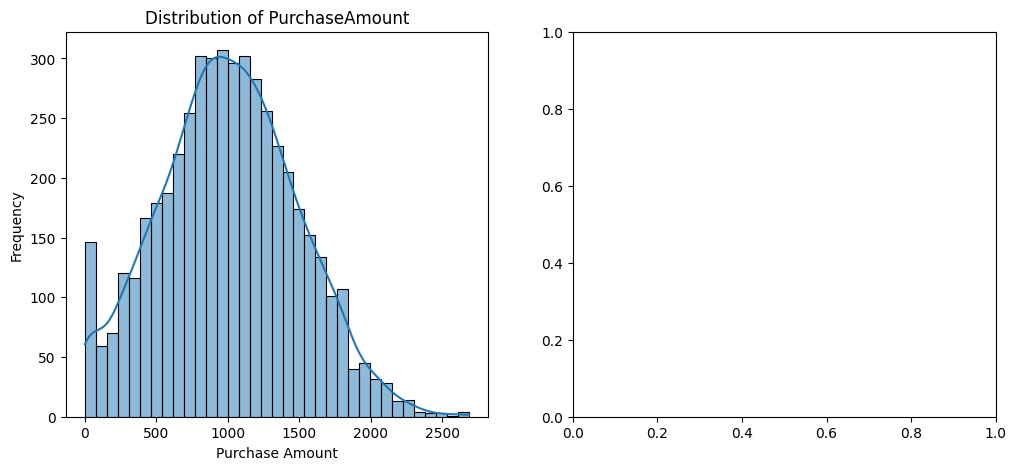

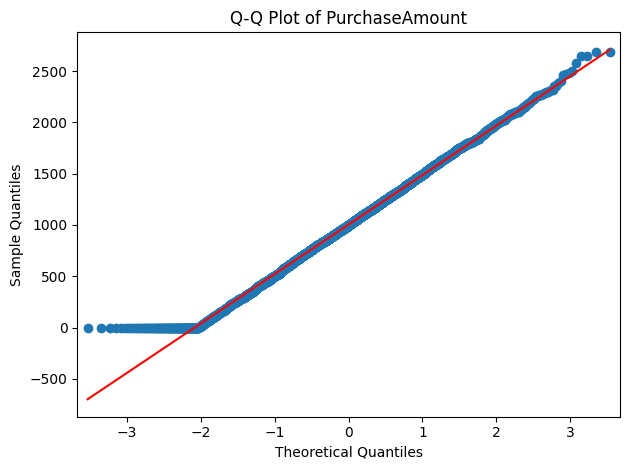

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Drop NaN values from PurchaseAmount for plotting
purchase_amount_data = df['PurchaseAmount'].dropna()

plt.figure(figsize=(12, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
sns.histplot(purchase_amount_data, kde=True)
plt.title('Distribution of PurchaseAmount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')

# Subplot 2: Q-Q Plot
plt.subplot(1, 2, 2)
sm.qqplot(purchase_amount_data, line='s') # 's' for standardized line
plt.title('Q-Q Plot of PurchaseAmount')

plt.tight_layout()
plt.show()

In [ ]:
#9. What insights can we gain by applying the Central Limit Theorem?

The Central Limit Theorem (CLT) is a powerful concept in statistics, and it can provide several key insights, especially in the context of our PurchaseAmount data, even though the individual distribution is already reasonably normal:

Justification for Parametric Tests: Even if the PurchaseAmount distribution were not close to normal (e.g., heavily skewed), the CLT tells us that the sampling distribution of the mean PurchaseAmount would tend towards a normal distribution as the sample size increases. This is crucial because many statistical tests (like the t-test and ANOVA that we used) assume normality of the sampling distribution of the means. The large sample size in our dataset (around 5000 observations) helps ensure that these tests are robust, even if the underlying individual PurchaseAmount distribution had some deviations from normality.

Reliability of Sample Means: The CLT gives us confidence that if we were to take multiple samples of customer purchase amounts, the average of those samples would be a reliable estimate of the true average PurchaseAmount in the entire customer population. This allows us to make inferences about the population mean based on our sample data with a known level of precision.

Confidence Intervals: The CLT is the theoretical basis for constructing confidence intervals for population parameters (like the mean PurchaseAmount). Because the sampling distribution of the mean is approximately normal, we can use properties of the normal distribution to quantify the uncertainty around our sample mean estimate. For example, we could construct a 95% confidence interval for the average PurchaseAmount of all customers, giving us a range within which the true population mean is likely to fall.

Hypothesis Testing: As mentioned before, the CLT underpins the validity of many hypothesis tests. When we perform tests like the t-test or ANOVA, we are often examining differences between sample means. The CLT ensures that the test statistics (like the t-statistic or F-statistic) will follow their theoretical distributions (t-distribution, F-distribution) under the null hypothesis, allowing us to correctly calculate p-values and make decisions about statistical significance.

In essence, the CLT allows us to generalize our findings from the sample PurchaseAmount data to the larger customer population with greater confidence, even if the raw data isn't perfectly normal. It provides the statistical backbone for many of the inferential conclusions we draw.

In [ ]:
#10.What is the 95% confidence interval for the average PurchaseAmount?

In [14]:
import numpy as np
from scipy import stats

# Drop NaN values from PurchaseAmount
purchase_amount_data = df['PurchaseAmount'].dropna()

# Calculate sample statistics
sample_mean = purchase_amount_data.mean()
sample_std = purchase_amount_data.std()
sample_size = len(purchase_amount_data)

# Calculate the standard error of the mean
standard_error = sample_std / np.sqrt(sample_size)

# Define the confidence level
confidence_level = 0.95
alpha = 1 - confidence_level

# Calculate the t-critical value for a 95% confidence interval
# Degrees of freedom = sample_size - 1
t_critical = stats.t.ppf(1 - alpha / 2, df=sample_size - 1)

# Calculate the margin of error
margin_of_error = t_critical * standard_error

# Calculate the confidence interval
confidence_interval_lower = sample_mean - margin_of_error
confidence_interval_upper = sample_mean + margin_of_error

print(f"Sample Mean Purchase Amount: {sample_mean:.2f}")
print(f"Sample Size: {sample_size}")
print(f"Standard Error of the Mean: {standard_error:.2f}")
print(f"T-critical value (for {confidence_level*100}% CI): {t_critical:.2f}")
print(f"Margin of Error: {margin_of_error:.2f}")
print(f"\n95% Confidence Interval for Average Purchase Amount: ({confidence_interval_lower:.2f}, {confidence_interval_upper:.2f})")

Sample Mean Purchase Amount: 1003.95
Sample Size: 4850
Standard Error of the Mean: 6.92
T-critical value (for 95.0% CI): 1.96
Margin of Error: 13.57

95% Confidence Interval for Average Purchase Amount: (990.38, 1017.52)
